# **Decision Tree Classifier – Solution Notebook**

## **Objective**

Diabetes is a common health condition that can cause serious complications if it is not detected early. Patient information such as glucose level, blood pressure, BMI, insulin level, age, and pregnancy history can help identify the risk of diabetes. The objective of this notebook is to build a decision tree classifier that predicts whether a patient is diabetic or non-diabetic. In the target column, `0` represents a non-diabetic patient and `1` represents a diabetic patient. Recall is selected as the primary model-selection metric because missing a patient who has diabetes is an important concern. Precision, recall, F1-score, and ROC-AUC will be used to evaluate the models. The training and testing recall of the baseline and tuned models will also be compared to check for overfitting.

## **Import Libraries**

Import the libraries required for data handling, visualisation, model building, tuning, and evaluation.

In [1]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline

# **Understanding the Dataset**

## **Task 1**
- Load the diabetes dataset
- Inspect its structure using `df.info()`
- Check for missing values

In [2]:
df = pd.read_csv('diabetes_dataset.csv'); df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
missing_values = df.isnull().sum(); missing_values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## **Task 2**
- Display the count of `'diabetic'` and `'non-diabetic'` patients using readable labels
- Visualise the number of diabetic and non-diabetic patients in a `countplot()`

In [5]:
df['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'}).value_counts()

Outcome
Non-Diabetic    500
Diabetic        268
Name: count, dtype: int64

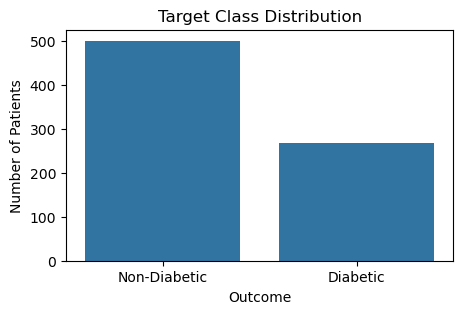

In [6]:
plt.figure(figsize = (5, 3))
sns.countplot(data = df, x = 'Outcome')
plt.title('Target Class Distribution'); plt.xlabel('Outcome'); plt.ylabel('Number of Patients')
plt.xticks([0, 1], ['Non-Diabetic', 'Diabetic'])
plt.show()

# **Data Preparation and Baseline Model**

## **Task 3**
Separate the predictor features and target variable, then create stratified training and testing sets.

In [7]:
X = df.drop('Outcome', axis = 1); y = df['Outcome']; print('Shape of X:', X.shape); print('Shape of y:', y.shape)

Shape of X: (768, 8)
Shape of y: (768,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)
print('Training set shape:', X_train.shape); print('Testing set shape:', X_test.shape)

Training set shape: (614, 8)
Testing set shape: (154, 8)


## **Task 4**
- Train the baseline decision tree
- Calculate the baseline model’s training and testing performance

In [9]:
baseline_model = DecisionTreeClassifier(criterion = 'gini', max_depth = 5, min_samples_split = 10, min_samples_leaf = 5, random_state = 42)
baseline_model.fit(X_train, y_train)
baseline_train_pred = baseline_model.predict(X_train)
baseline_test_pred = baseline_model.predict(X_test)
baseline_test_probability = baseline_model.predict_proba(X_test)[:, 1]

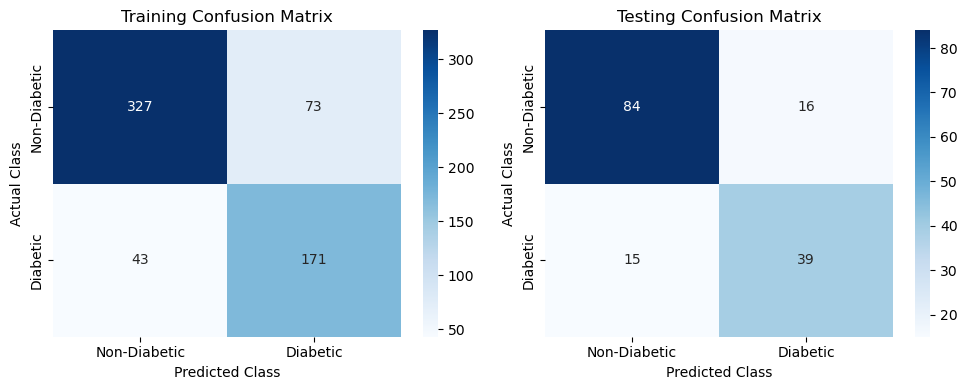

In [10]:
cm_train = confusion_matrix(y_train, baseline_train_pred)
cm_test = confusion_matrix(y_test, baseline_test_pred)
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm_train, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Non-Diabetic', 'Diabetic'],
            yticklabels = ['Non-Diabetic', 'Diabetic'])
plt.title('Training Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.subplot(1, 2, 2)
sns.heatmap(cm_test, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Non-Diabetic', 'Diabetic'],
            yticklabels = ['Non-Diabetic', 'Diabetic'])
plt.title('Testing Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

In [11]:
baseline_train_recall = recall_score(y_train, baseline_train_pred)
baseline_test_precision = precision_score(y_test, baseline_test_pred)
baseline_test_recall = recall_score(y_test, baseline_test_pred)
baseline_test_f1 = f1_score(y_test, baseline_test_pred)
baseline_test_roc_auc = roc_auc_score(y_test, baseline_test_probability)

In [12]:
print('Baseline Training Recall:', round(baseline_train_recall, 3))
print('Baseline Testing Precision:', round(baseline_test_precision, 3))
print('Baseline Testing Recall:', round(baseline_test_recall, 3))
print('Baseline Testing F1-Score:', round(baseline_test_f1, 3))
print('Baseline Testing ROC-AUC:', round(baseline_test_roc_auc, 3))

Baseline Training Recall: 0.799
Baseline Testing Precision: 0.709
Baseline Testing Recall: 0.722
Baseline Testing F1-Score: 0.716
Baseline Testing ROC-AUC: 0.796


## **Task 5**
- Display the depth and total number of leaves in the baseline decision tree
- Compare the baseline model’s training and testing recall, and calculate the recall gap to check for possible overfitting

In [13]:
print('Baseline Tree Depth:', baseline_model.get_depth())
print('Baseline Number of Leaves:', baseline_model.get_n_leaves())

Baseline Tree Depth: 5
Baseline Number of Leaves: 20


In [14]:
baseline_recall_gap = baseline_train_recall - baseline_test_recall
print('Training Recall:', round(baseline_train_recall, 3)); print('Testing Recall:', round(baseline_test_recall, 3))
print('Recall Gap:', round(baseline_recall_gap, 3))

Training Recall: 0.799
Testing Recall: 0.722
Recall Gap: 0.077


## **Task 6**
Visualise the first few levels of the baseline decision tree

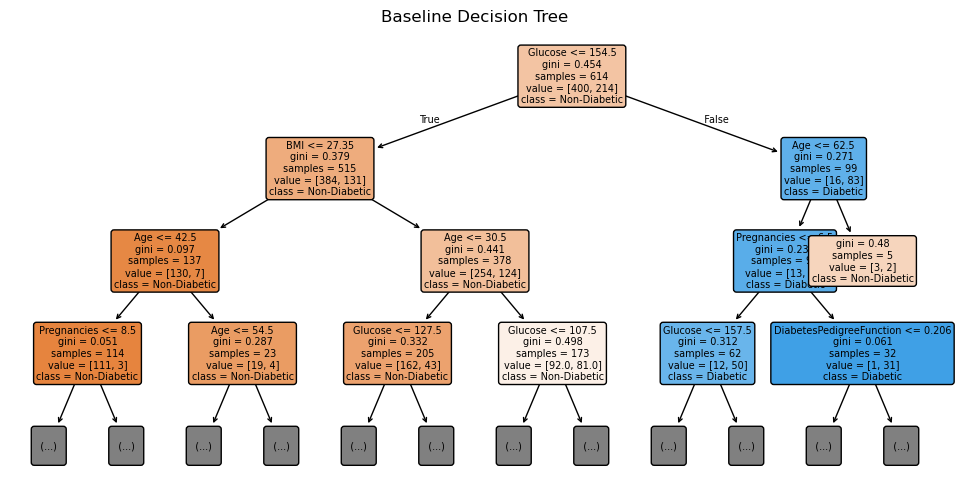

In [15]:
plt.figure(figsize = (12, 6))
plot_tree(baseline_model, feature_names = X_train.columns, class_names = ['Non-Diabetic', 'Diabetic'],
          filled = True, rounded = True, max_depth = 3, fontsize = 7)
plt.title('Baseline Decision Tree')
plt.show()

## **Task 7**
Display the top three most important features of the baseline decision tree model

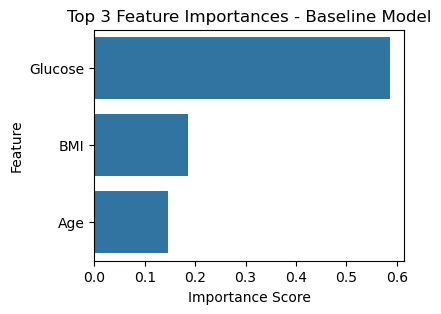

In [16]:
baseline_importance = pd.DataFrame({'Feature': X_train.columns, 'Importance': baseline_model.feature_importances_})
baseline_importance = baseline_importance.sort_values(by = 'Importance', ascending = False).head(3)
plt.figure(figsize = (4, 3))
sns.barplot(data = baseline_importance, x = 'Importance', y = 'Feature')
plt.title('Top 3 Feature Importances - Baseline Model'); plt.xlabel('Importance Score'); plt.ylabel('Feature')
plt.show()

# **Hyperparameter Tuning**

## **Task 8**
Define the decision tree hyperparameter values that will be tested during tuning

In [17]:
param_grid = {'criterion': ['gini', 'entropy'],
              'max_depth': [2, 3, 4, 5, 6],
              'min_samples_split': [2, 5, 10],
              'min_samples_leaf': [1, 2, 5],
              'class_weight': [None, 'balanced']}
print(param_grid)

{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, 4, 5, 6], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 5], 'class_weight': [None, 'balanced']}


## **Task 9**
- Tune the decision tree using five-fold cross-validation and recall as the scoring metric
- Display the best hyperparameters, best cross-validation recall, and the best trained decision tree selected by GridSearchCV

In [18]:
decision_tree_model = DecisionTreeClassifier(random_state = 42)
grid_search = GridSearchCV(estimator = decision_tree_model, param_grid = param_grid, scoring = 'recall', cv = 5, verbose = 10)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 180 candidates, totalling 900 fits
[CV 1/5; 1/180] START class_weight=None, criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2
[CV 1/5; 1/180] END class_weight=None, criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2;, score=0.465 total time=   0.0s
[CV 2/5; 1/180] START class_weight=None, criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2
[CV 2/5; 1/180] END class_weight=None, criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2;, score=0.442 total time=   0.0s
[CV 3/5; 1/180] START class_weight=None, criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2
[CV 3/5; 1/180] END class_weight=None, criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2;, score=0.279 total time=   0.0s
[CV 4/5; 1/180] START class_weight=None, criterion=gini, max_depth=2, min_samples_leaf=1, min_samples_split=2
[CV 4/5; 1/180] END class_weight=None, criterion=gini, max_depth=2, min_sa

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 3, 4, 5, 6],
                         'min_samples_leaf': [1, 2, 5],
                         'min_samples_split': [2, 5, 10]},
             scoring='recall', verbose=10)

In [19]:
print('Best Hyperparameters:' + str(grid_search.best_params_))
print('\nBest Cross-Validation Recall:' + str(round(grid_search.best_score_, 3)))
print('\nBest Final Model:' + str(grid_search.best_estimator_))

Best Hyperparameters:{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}

Best Cross-Validation Recall:0.827

Best Final Model:DecisionTreeClassifier(class_weight='balanced', max_depth=3, min_samples_leaf=5,
                       random_state=42)


# **Final Model Evaluation and Interpretation**

## **Task 10**
- Store the best tuned decision tree, generate predictions, and find out its training and testing recall
- Compare the final model’s training and testing recall, and calculate the recall gap to check whether the model may be overfitting

In [20]:
final_model = grid_search.best_estimator_
final_train_pred = final_model.predict(X_train); final_test_pred = final_model.predict(X_test)
final_train_recall = recall_score(y_train, final_train_pred); final_test_recall = recall_score(y_test, final_test_pred)
print('Final Training Recall:', round(final_train_recall, 3)); print('Final Testing Recall:', round(final_test_recall, 3))

Final Training Recall: 0.897
Final Testing Recall: 0.87


In [21]:
final_recall_gap = final_train_recall - final_test_recall
print('Training Recall:', round(final_train_recall, 3)); print('Testing Recall:', round(final_test_recall, 3))
print('Recall Gap:', round(final_recall_gap, 3))

Training Recall: 0.897
Testing Recall: 0.87
Recall Gap: 0.027


## **Task 11**
Display the patient feature values with their actual and predicted labels

In [22]:
prediction_df = X_test.copy()
prediction_df['Actual Outcome'] = y_test.values; prediction_df['Predicted Outcome'] = final_test_pred
prediction_df.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Actual Outcome,Predicted Outcome
437,5,147,75,0,0,29.9,0.434,28,0,1
185,7,194,68,28,0,35.9,0.745,41,1,1
351,4,137,84,0,0,31.2,0.252,30,0,1
75,1,0,48,20,0,24.7,0.140,22,0,0
424,8,151,78,32,210,42.9,0.516,36,1,1
305,2,120,76,37,105,39.7,0.215,29,0,1
698,4,127,88,11,155,34.5,0.598,28,0,1
264,4,123,62,0,0,32.0,0.226,35,1,1
650,1,91,54,25,100,25.2,0.234,23,0,0
13,1,189,60,23,846,30.1,0.398,59,1,1


## **Task 12**
Create confusion matrices to compare the actual and predicted classes for training and testing sets

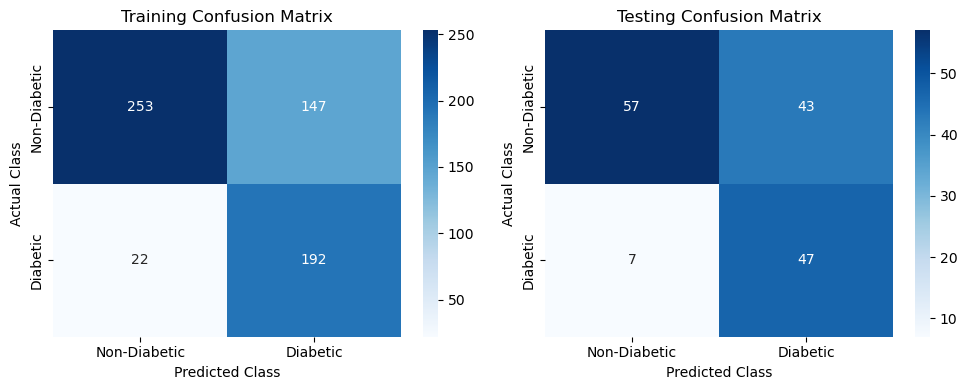

In [23]:
cm_train = confusion_matrix(y_train, final_train_pred)
cm_test = confusion_matrix(y_test, final_test_pred)
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
sns.heatmap(cm_train, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Non-Diabetic', 'Diabetic'],
            yticklabels = ['Non-Diabetic', 'Diabetic'])
plt.title('Training Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.subplot(1, 2, 2)
sns.heatmap(cm_test, annot = True, fmt = 'd', cmap = 'Blues',
            xticklabels = ['Non-Diabetic', 'Diabetic'],
            yticklabels = ['Non-Diabetic', 'Diabetic'])
plt.title('Testing Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()

## **Task 13**
Evaluate the final model using precision, recall, F1-score, and ROC-AUC

In [24]:
final_precision = precision_score(y_test, final_test_pred)
final_f1 = f1_score(y_test, final_test_pred)
final_probability = final_model.predict_proba(X_test)[:, 1]
final_roc_auc = roc_auc_score(y_test, final_probability)
print('Precision:', round(final_precision, 3))
print('Recall:', round(final_test_recall, 3))
print('F1-Score:', round(final_f1, 3))
print('ROC-AUC:', round(final_roc_auc, 3))

Precision: 0.522
Recall: 0.87
F1-Score: 0.653
ROC-AUC: 0.8


## **Task 14**
Visualise the first few levels of the final decision tree

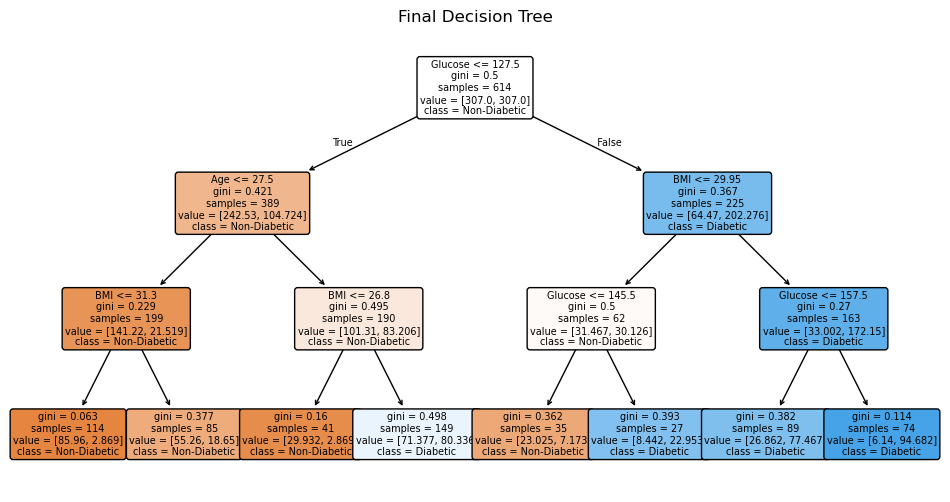

In [25]:
plt.figure(figsize = (12, 6))
plot_tree(final_model, feature_names = X_train.columns, class_names = ['Non-Diabetic', 'Diabetic'],
          filled = True, rounded = True, max_depth = 3, fontsize = 7)
plt.title('Final Decision Tree')
plt.show()

## **Task 15**
Compare the recall and overfitting gap of the baseline and final models

In [26]:
model_comparison = pd.DataFrame({'Model': ['Baseline Model', 'Final Model'],
                                 'Training Recall': [baseline_train_recall, final_train_recall],
                                 'Testing Recall': [baseline_test_recall, final_test_recall],
                                 'Recall Gap': [baseline_recall_gap, final_recall_gap]})
model_comparison.round(3)

,Model,Training Recall,Testing Recall,Recall Gap
0,Baseline Model,0.799,0.722,0.077
1,Final Model,0.897,0.870,0.027
